# Zipf's Law

In [2]:
with open("../data/processed/don_quixote.txt", "r", encoding="utf-8") as textfile:
    data = textfile.read().split()
# data = ["hello", "hello", "world"]  # This is a placeholder list containing the tokens

data_count = {}

for token in data:
    current_count = data_count.get(token, 0)
    data_count[token] = current_count + 1

In [3]:
import matplotlib.pyplot as plt
import numpy as np

import numpy as np

counts = np.array(list(data_count.values()))
counts = np.sort(counts)[::-1]
rank = np.arange(1, len(counts) + 1)

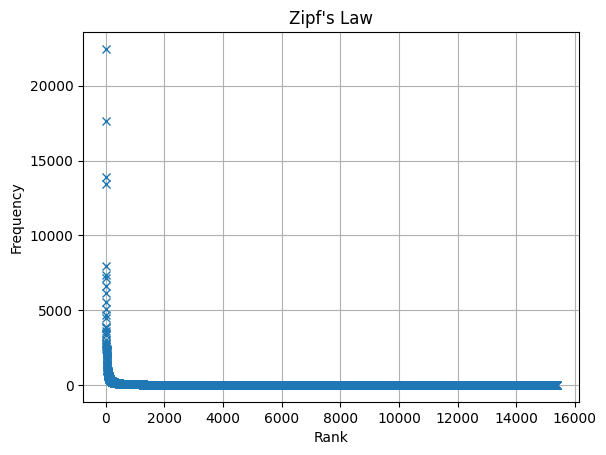

In [4]:
plt.plot(rank, counts, "x")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf's Law")
plt.grid()
# plt.savefig("Images/50_words.png", dpi=1000)
plt.show()

As these axis ranges skew the data such that the main pattern is not visible at first glance, we can limit the x-range to 0-150 to mitigate this.

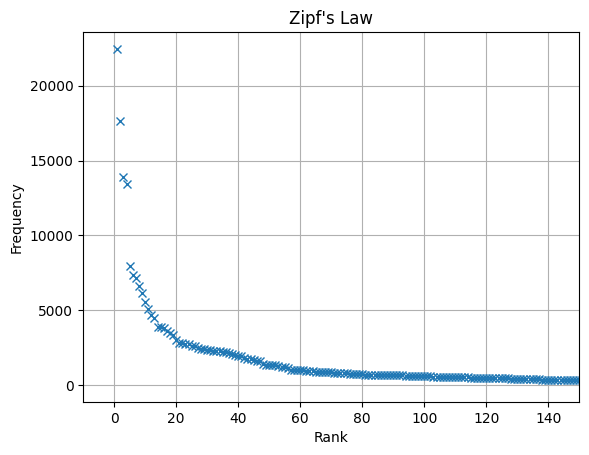

In [5]:
plt.plot(rank, counts, "x")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf's Law")
plt.xlim(-10, 150)
plt.grid()
# plt.savefig("Images/50_words.png", dpi=1000)
plt.show()

As per initial inspection, these results are as expected, we can proceed to log-log plot this graph to verify Zipf's law behaviour as:

$$
f(x) = \alpha x^\beta
$$

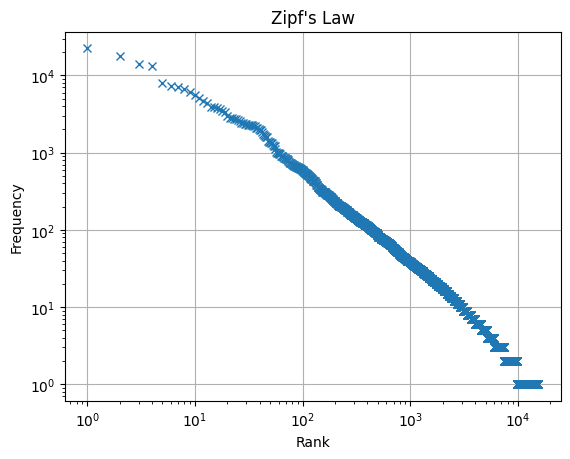

In [6]:
plt.loglog(rank, counts, "x")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf's Law")
plt.grid()
plt.show()

The above graph shows non-negligible straight-line behaviour. Therefore we can proceed with non-linear regression in a similar fashion to Heaps' law analysis to account for the non-normal residuals.

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(np.log(rank).reshape(-1, 1), np.log(counts).reshape(-1, 1))
beta_ols = model.coef_[0][0]
alpha_ols = np.exp(model.intercept_[0])
print(f"Fitted parameters: alpha = {alpha_ols:.4f}, beta = {beta_ols:.4f}")


from scipy.optimize import curve_fit


def zipf(x, alpha, beta):
    return alpha * x**beta


(alpha, beta), pcov = curve_fit(zipf, rank, counts)
print(f"The zipf law results are: {alpha:.0f} ± {pcov[0][0]:.0f} * rank ^ ({beta:.2f} ± {pcov[1][1]:.2f})")

Fitted parameters: alpha = 521924.5546, beta = -1.3810
The zipf law results are: 27128 ± 4189 * rank ^ (-0.79 ± 0.00)


We can now visually inspect these results in a visual form as follows:

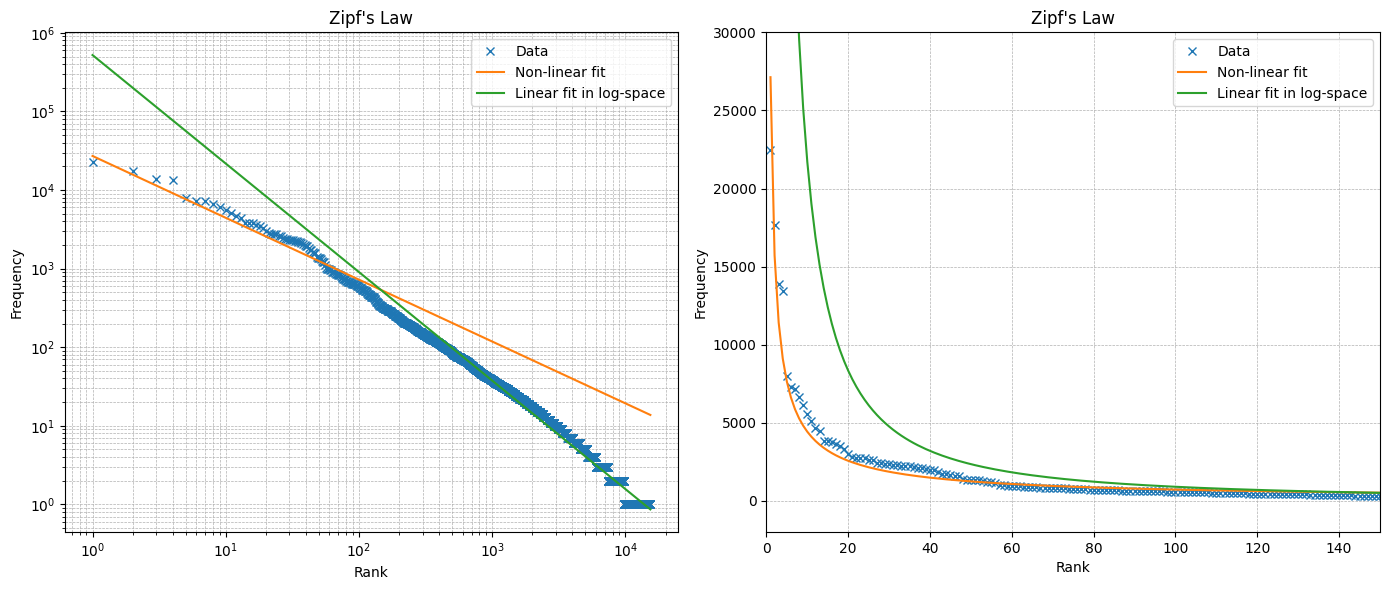

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].loglog(rank, counts, "x", label="Data")
ax[0].plot(rank, alpha * rank**beta, label="Non-linear fit")
ax[0].plot(rank, alpha_ols * rank**beta_ols, label="Linear fit in log-space")
ax[0].set_xlabel("Rank")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Zipf's Law")
ax[0].grid(True, which="both", linestyle="--", linewidth=0.5)
ax[0].legend()

ax[1].plot(rank, counts, "x", label="Data")
ax[1].plot(rank, alpha * rank**beta, label="Non-linear fit")
ax[1].plot(rank, alpha_ols * rank**beta_ols, label="Linear fit in log-space")
ax[1].set_xlim(0, 150)
ax[1].set_ylim(-2000, 30000)
ax[1].set_xlabel("Rank")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Zipf's Law")
ax[1].grid(True, which="both", linestyle="--", linewidth=0.5)
ax[1].legend()

plt.tight_layout()
plt.show()

As we can see from the above, linear regression suffers from significant leverage issues due to many points having high ranks and low frequencies but the non-linear fit suffers from the opposite (although being more statistically rigurous. A hybrid approach (combining the two up until their respective intersections) may be considered.

Again, we can try to circumvent the leverage issues by binning the data into logarithmic bins and plotting the mean of each bin.

In [40]:
num_bins = 20
ranks_binned = np.logspace(1, np.log10(len(rank)), num_bins + 1, dtype=np.uint32)
counts_binned = np.zeros(num_bins)
for i, (bottom_rank, top_rank) in enumerate(zip(ranks_binned[:-1], ranks_binned[1:])):
    counts_slice = counts[(rank >= bottom_rank) & (rank < top_rank)]
    if len(counts_slice) > 0:
        counts_binned[i] = np.mean(counts_slice)
    else:
        counts_binned[i] = 0
ranks_binned_midpoints = (ranks_binned[:-1] + ranks_binned[1:]) / 2

In [41]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(np.log(ranks_binned_midpoints).reshape(-1, 1), np.log(counts_binned).reshape(-1, 1))
beta_binned_ols = model.coef_[0][0]
alpha_binned_ols = np.exp(model.intercept_[0])
print(f"Fitted parameters: alpha = {alpha_binned_ols:.4f}, beta = {beta_binned_ols:.4f}")


from scipy.optimize import curve_fit


def zipf(x, alpha, beta):
    return alpha * x**beta


(alpha_binned, beta_binned), pcov = curve_fit(zipf, ranks_binned_midpoints, counts_binned)
print(
    f"The zipf law results are: {alpha_binned:.0f} ± {pcov[0][0]:.0f} * rank ^ ({beta_binned:.2f} ± {pcov[1][1]:.2f})"
)

Fitted parameters: alpha = 141107.9844, beta = -1.2084
The zipf law results are: 50528 ± 18756541 * rank ^ (-0.93 ± 0.00)


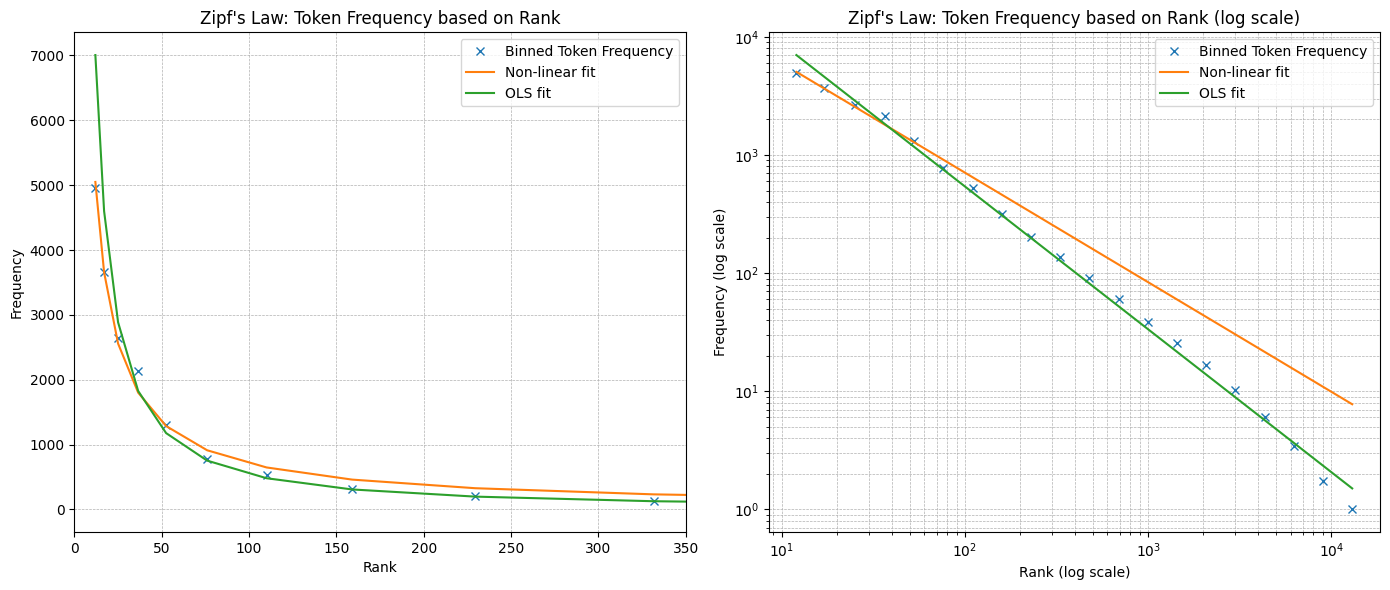

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].plot(ranks_binned_midpoints, counts_binned, "x", label="Binned Token Frequency")
ax[0].plot(ranks_binned_midpoints, alpha_binned * ranks_binned_midpoints**beta_binned, label="Non-linear fit")
ax[0].plot(ranks_binned_midpoints, alpha_binned_ols * ranks_binned_midpoints**beta_binned_ols, label="OLS fit")
ax[0].set_xlabel("Rank")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Zipf's Law: Token Frequency based on Rank")
ax[0].set_xlim(0, 350)
ax[0].grid(True, which="both", linestyle="--", linewidth=0.5)
ax[0].legend()

ax[1].plot(ranks_binned_midpoints, counts_binned, "x", label="Binned Token Frequency")
ax[1].plot(ranks_binned_midpoints, alpha_binned * ranks_binned_midpoints**beta_binned, label="Non-linear fit")
ax[1].plot(ranks_binned_midpoints, alpha_binned_ols * ranks_binned_midpoints**beta_binned_ols, label="OLS fit")
ax[1].set_xlabel("Rank (log scale)")
ax[1].set_ylabel("Frequency (log scale)")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_title("Zipf's Law: Token Frequency based on Rank (log scale)")
ax[1].grid(True, which="both", linestyle="--", linewidth=0.5)
ax[1].legend()

plt.tight_layout()
plt.show()